In [ ]:
import os
os.chdir(r'D:\work\working_files\bscore_retrain\src')
import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy.stats import kstest
from FeatureTransformers.WOEPandas import WOEProcessTransformer
from FeatureSelectors.CorrelationSelector import TopCorrelationSelector
from Evaluators.GiniSk import gini_score
import json

### Load model

In [13]:
# Load registered model from MLflow
mlflow.set_tracking_uri('http://10.2.120.54:5000')
model_name = "bscore"  # Replace with your model's name
model_version = "1"  # Replace with your model's version, or use "latest" to get the latest version
logged_model = f"models:/{model_name}/{model_version}"
# Load the model from MLflow
model = mlflow.sklearn.load_model(logged_model)

In [25]:
with open("../configs/bscore_config.json", 'r') as file:
    proj_conf = json.load(file)

In [15]:
test_data = pd.read_parquet(r"..\data\bscore_cc_test.parquet")

In [29]:
features_list = test_data.columns.to_list()
unused_cols = proj_conf["not_features"]
if proj_conf["target"] not in unused_cols:
    unused_cols.append(proj_conf["target"])
for element in unused_cols:
    features_list.remove(element)

target_col = proj_conf["target"]

X_test = test_data[features_list]
y_test = test_data[target_col] 

In [37]:
test_prob = model.predict_proba(X_test)[:, 1]
test_pred = model.predict(X_test)
test_prob

array([0.00378258, 0.00179909, 0.00378258, ..., 0.01091238, 0.00321483,
       0.00782014])

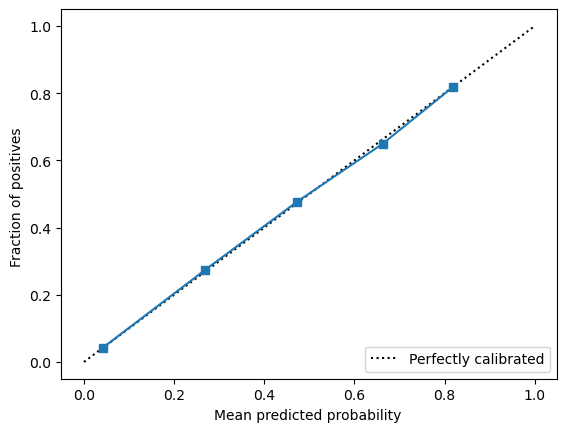

In [35]:
prob_true, prob_pred = calibration_curve(y_test, test_prob, pos_label=1)
CalibrationDisplay(prob_true, prob_pred, test_prob).plot()

In [36]:
gini_score(y_test, test_prob)

0.6844060411995954

In [ ]:
kstest()